# Convnextの学習曲線の評価


左：Deletionデータによってクラス条件付きモーメントをk次までなるべく保存したデータセットで学習したもの．
右：左と同じだが，entropy-maximizingの正則化を行ったもので学習したもの．


\caption{Test accuracy learning curves for ConvNeXt-atto trained on moment-edited
CIFAR-10 surrogates, evaluated on the real CIFAR-10 test set throughout training
(mean $\pm$ 1 std.\ across seeds where multiple seeds are available; single-seed
runs shown as a line only). \textbf{Left:} Gram-trick (no-entropy) surrogates.
\textbf{Right:} KoLeo-regularized (entropy-maximizing) surrogates. The black curve
(\textit{real}) is the model trained on unedited CIFAR-10 and serves as an upper
reference in both panels. Step axis is log-scaled.}


図X: モーメント編集CIFAR-10代理データで学習したConvNeXt-attoの、実CIFAR-10テストセット
に対するtest_accの学習曲線(複数seedが揃っている条件は平均±標準偏差、単一seedの条件は
線のみ)。左: Gram trick(エントロピー項なし)による代理データ。右: KoLeo正則化
(エントロピー最大化)による代理データ。黒線(real)は未編集のCIFAR-10で学習したモデルで、
両パネル共通の上限参照として示す。横軸(step)は対数スケール。


図Xは、2種類のモーメント編集代理データで学習したConvNeXt-attoのtest_acc推移を比較した
ものである。エントロピー項なし(Gram trick)条件では、モーメント次数が上がるほどtest_acc
が単調に増加し、1次(約0.28)から4次(約0.84)まで明確な階層構造が確認できる。これは、
より高次のモーメントに制約された代理データほど、実画像への汎化に必要な情報をより多く
保持しているという予想と整合する。

KoLeo条件でも、Gram trick条件と同様の次数による順序構造自体は保たれている。1次KoLeoは
ほぼチャンスレート付近(約0.29)にとどまり、2次(約0.54)・3次(約0.58)は明確に分離して
いる。一方、4次・5次・6次KoLeo(約0.60〜0.65)は互いに接近し、seed間のばらつき(標準偏差
の帯)が重なり合うほど僅差になっている。この「次数が上がるほど分離が圧縮される」という
パターンは、エントロピー最大化が次数由来のシグナルを完全に消し去るわけではないものの、
次数が上がるにつれてエントロピー項の寄与が相対的に支配的になり、次数間の分離を圧縮する
交絡変数として働いていることと整合的である。この点についてはSection Xで、対応するLLC
測定の結果と合わせて再検討する。

注: third_order_gram、fourth_order_gram、およびKoLeo系の全条件は3seed(42, 43, 44)の
平均値であり、first_order_gramとsecond_order_gramは単一seed(42)のみの結果である点に
留意されたい。

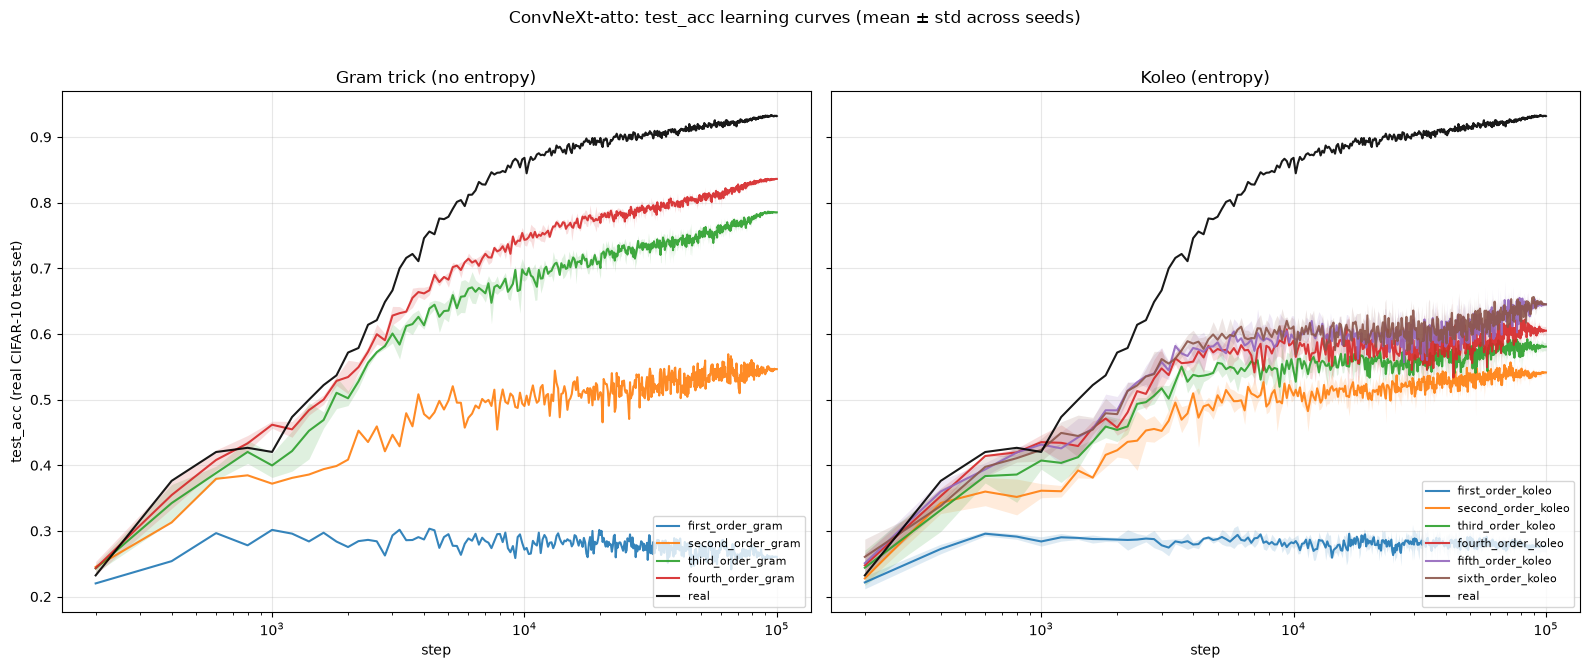

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LLC_DIR = "/home/nakano/server/llc_results_dense"

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

convnext_files = {
    "first_order_gram":  [f"{LLC_DIR}/deletion_vision_first_order_gram_convnext_seed42.jsonl"],
    "second_order_gram": [f"{LLC_DIR}/deletion_vision_second_order_gram_convnext_seed42.jsonl"],
    "third_order_gram":  [f"{LLC_DIR}/deletion_vision_third_order_gram_convnext_seed{s}.jsonl" for s in (42, 43, 44)],
    "fourth_order_gram": [f"{LLC_DIR}/deletion_vision_fourth_order_gram_convnext_seed{s}.jsonl" for s in (42, 43, 44)],
    "first_order_koleo":  [f"{LLC_DIR}/deletion_vision_first_order_koleo_convnext-atto.jsonl"],
    "second_order_koleo": [f"{LLC_DIR}/deletion_vision_second_order_koleo_convnext-atto.jsonl"],
    "third_order_koleo":  [f"{LLC_DIR}/deletion_vision_third_order_koleo_convnext-atto.jsonl"],
    "fourth_order_koleo": [f"{LLC_DIR}/deletion_vision_fourth_order_koleo_convnext-atto.jsonl"],
    "fifth_order_koleo":  [f"{LLC_DIR}/deletion_vision_fifth_order_koleo_convnext-atto.jsonl"],
    "sixth_order_koleo":  [f"{LLC_DIR}/deletion_vision_sixth_order_koleo_convnext-atto.jsonl"],
}

rows = []
for condition, paths in convnext_files.items():
    for p in paths:
        for r in load_jsonl(p):
            rows.append({
                "condition": condition,
                "seed": r["seed"],
                "step": r["step"],
                "test_acc": r["test_acc"],
            })

df = pd.DataFrame(rows)

real_df = pd.read_csv(f"{LLC_DIR}/deletion_vision_real_convnext_seed42.csv")
real_df["condition"] = "real"
real_df["seed"] = 42
df = pd.concat([df, real_df[["condition", "seed", "step", "test_acc"]]], ignore_index=True)

# seedごとの本数もカウントしておく(帯を出すかどうかの判定用)
stats_df = df.groupby(["condition", "step"], as_index=False).agg(
    mean_acc=("test_acc", "mean"),
    std_acc=("test_acc", "std"),
    n_seeds=("seed", "nunique"),
)

order_colors = {
    1: "tab:blue", 2: "tab:orange", 3: "tab:green",
    4: "tab:red", 5: "tab:purple", 6: "tab:brown",
}
order_names = {1: "first", 2: "second", 3: "third", 4: "fourth", 5: "fifth", 6: "sixth"}
name_to_order = {v: k for k, v in order_names.items()}

gram_conditions  = ["first_order_gram", "second_order_gram", "third_order_gram", "fourth_order_gram"]
# 後で追加！→5，6

koleo_conditions = ["first_order_koleo", "second_order_koleo", "third_order_koleo",
                     "fourth_order_koleo", "fifth_order_koleo", "sixth_order_koleo"]

def plot_condition(ax, condition, color, linestyle="-"):
    g = stats_df[stats_df["condition"] == condition].sort_values("step")
    ax.plot(g["step"], g["mean_acc"], label=condition, color=color, linestyle=linestyle, alpha=0.9)
    # 3seed(n_seeds>=2)揃っている場合のみ標準偏差の帯を表示
    if (g["n_seeds"] >= 2).any():
        ax.fill_between(g["step"], g["mean_acc"] - g["std_acc"], g["mean_acc"] + g["std_acc"],
                         color=color, alpha=0.15, linewidth=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)

# --- gram側 ---
ax = axes[0]
for condition in gram_conditions:
    order_key = condition.split("_")[0]
    color = order_colors.get(name_to_order.get(order_key), "gray")
    plot_condition(ax, condition, color)
plot_condition(ax, "real", "black")
ax.set_title("Gram trick (no entropy)")
ax.set_xlabel("step")
ax.set_xscale("log")
ax.set_ylabel("test_acc (real CIFAR-10 test set)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

# --- koleo側 ---
ax = axes[1]
for condition in koleo_conditions:
    order_key = condition.split("_")[0]
    color = order_colors.get(name_to_order.get(order_key), "gray")
    plot_condition(ax, condition, color)
plot_condition(ax, "real", "black")
ax.set_title("Koleo (entropy)")
ax.set_xlabel("step")
ax.set_xscale("log")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

plt.suptitle("ConvNeXt-atto: test_acc learning curves (mean ± std across seeds)", y=1.02)
plt.tight_layout()
plt.savefig("/home/nakano/cuda_test/convnext_learning_curves_split_std.png", dpi=120)
plt.show()